In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib import colormaps

In [4]:
Rosedata_df = pd.read_csv("Event_core_v4.csv")
print(Rosedata_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_date                    29 non-null     object 
 1   event_id                      29 non-null     object 
 2   parent_event_id               46 non-null     object 
 3   type                          46 non-null     object 
 4   location_id                   46 non-null     object 
 5   decimal_latitud               29 non-null     float64
 6   decimal_longitude             29 non-null     float64
 7   depth_m                       46 non-null     int64  
 8   habitat                       46 non-null     object 
 9   conteo_ind                    46 non-null     int64  
 10  temperat_grad_c               46 non-null     float64
 11  total_organic_matter_percent  46 non-null     float64
 12  proport_silt_clay_percent     46 non-null     int64  
 13  prop_si

In [5]:
def preprocess_data(df, variables):
    """
    Standardize selected variables and return clean DataFrame.
    """
    df_clean = df.dropna(subset=variables)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[variables])
    return df_clean, X_scaled

In [6]:
def perform_hierarchical_clustering(X_scaled, method='ward', n_clusters=3):
    """
    Perform hierarchical clustering and return cluster labels.
    """
    linkage_matrix = linkage(X_scaled, method=method)
    cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    return linkage_matrix, cluster_labels

In [7]:
def plot_dendrogram(linkage_matrix, labels=None, n_clusters=3):
    """
    Plot a dendrogram from the hierarchical clustering with sample labels.
    Annotate the plot with the number of clusters.
    """
    # Generate cluster labels
    cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

    plt.figure(figsize=(10, 5))
    dendrogram(
        linkage_matrix,
        labels=labels,
        above_threshold_color='gray'  # Default color for links above the threshold
    )
    plt.title(f'Hierarchical Clustering Dendrogram\n(Number of Clusters: {n_clusters})')
    plt.xlabel('Sample Labels')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()

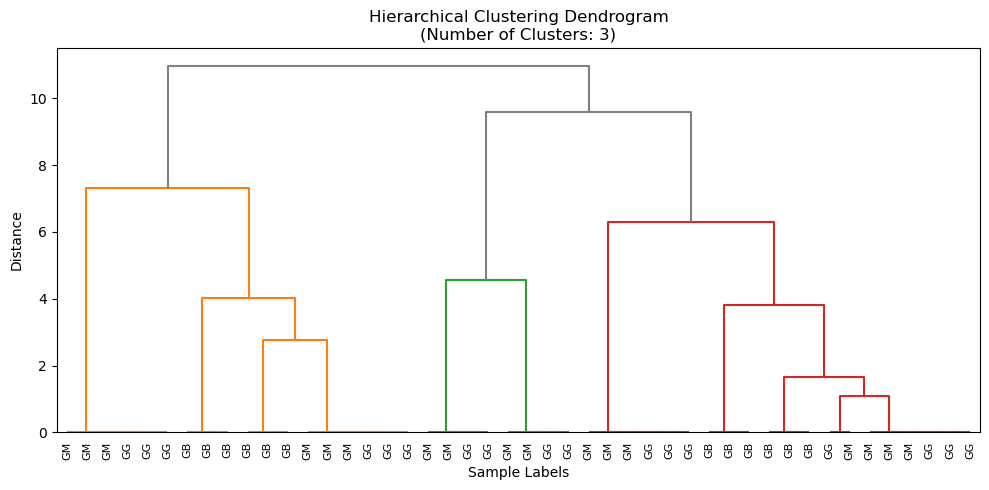

In [10]:
# Main workflow

# Select variables for clustering
selected_vars = ['depth_m', 'total_organic_matter_percent', 'temperat_grad_c', 'proport_silt_clay_percent']

# Preprocess the data; Drop rows with missing values in selected variables
# Standardize the selected variables using StandardScaler
df_clean, X_scaled = preprocess_data(Rosedata_df, selected_vars)

# Perform hierarchical clustering using the 'ward' method 
# The number of clusters to be 3. You can adjust the number of clusters as needed
linkage_matrix, clusters = perform_hierarchical_clustering(X_scaled, n_clusters=3)

# Add cluster labels to the DataFrame
df_clean['cluster'] = clusters

# Plot dendrogram using sample labels 
plot_dendrogram(linkage_matrix, labels=df_clean['parent_event_id'].values)

Tarea. Cambiar el número de cluster a 4:

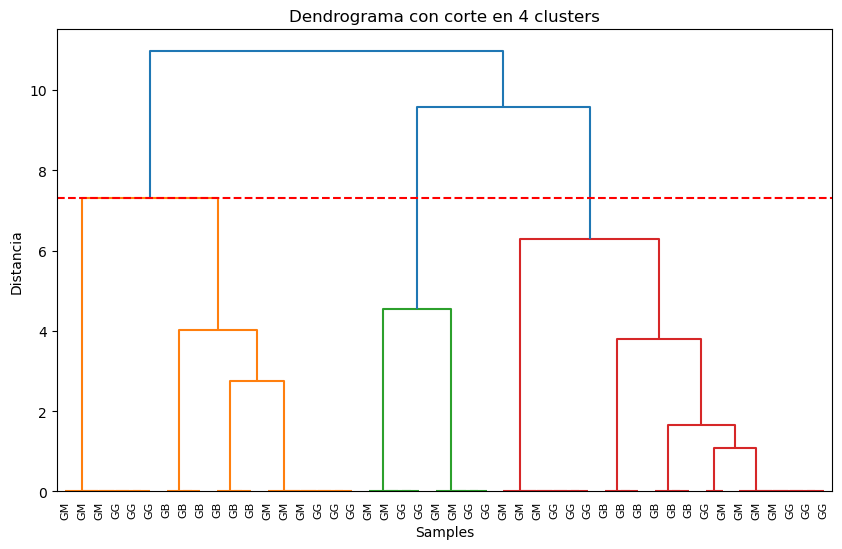

In [17]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(linkage_matrix, labels, n_clusters=4):
    plt.figure(figsize=(10, 6))
    dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=None  # Para controlar los colores de las ramas
    )
    
    # Calcular el umbral de altura correspondiente al número de clusters
    from scipy.cluster.hierarchy import fcluster
    cluster_assignments = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    # El umbral es la mínima distancia que separa los clusters
    threshold = linkage_matrix[-(n_clusters-1), 2]
    
    # Dibujar línea horizontal en el umbral
    plt.axhline(y=threshold, color='r', linestyle='--')
    
    plt.title(f'Dendrograma con corte en {n_clusters} clusters')
    plt.xlabel('Samples')
    plt.ylabel('Distancia')
    plt.show()

# Usar la función con tu linkage_matrix y labels
plot_dendrogram(linkage_matrix, labels=df_clean['parent_event_id'].values, n_clusters=4)

Comparación entre métodos:

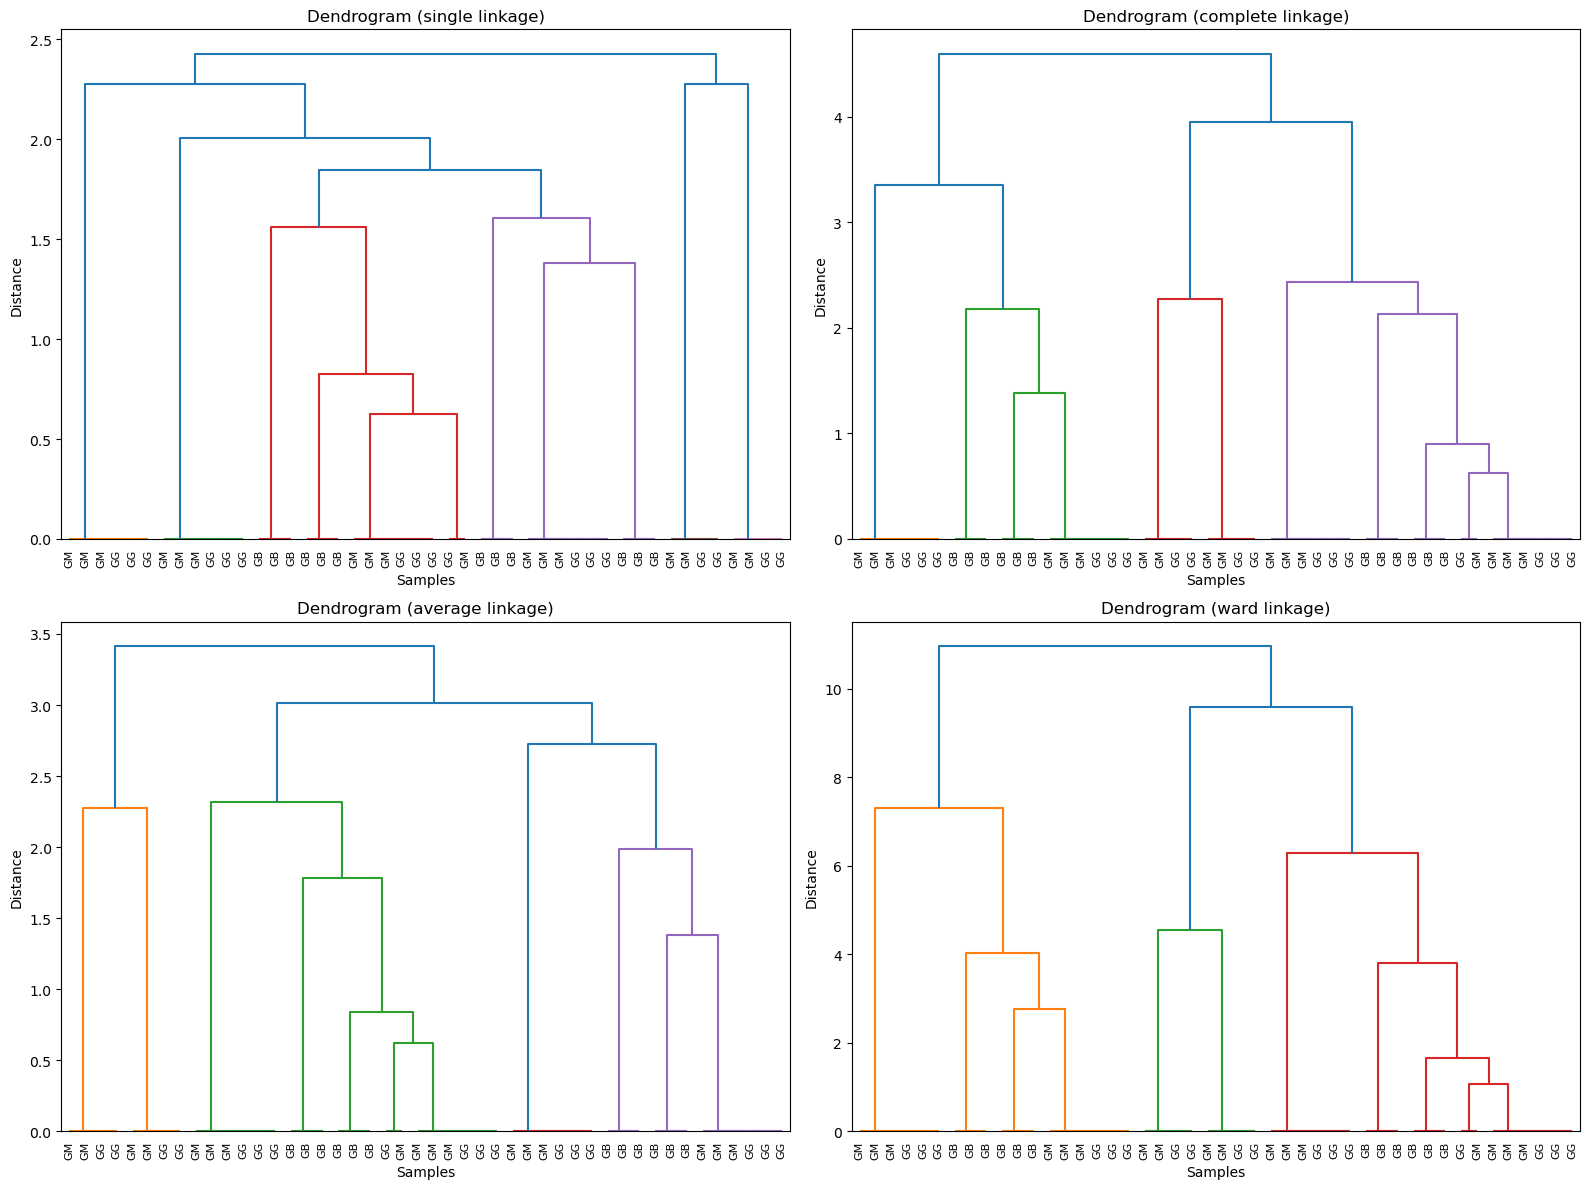

In [16]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(16, 12))

for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    linkage_matrix = linkage(X_scaled, method=method)
    dendrogram(linkage_matrix, labels=df_clean['parent_event_id'].values, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.xlabel('Samples')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()